# Imports e Setup

In [68]:
# Instalação das libs
#%pip install -q torchdiffeq==0.2.5
#%pip install pandas
#%pip install tabulate

In [69]:
import torch
import torch.nn as nn
import math
import sys
import os
import matplotlib.pyplot as plt
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from tabulate import tabulate
import torch

from sklearn.datasets import make_moons

In [70]:
# Adiciona a pasta mini_project_1 como root
sys.path.append(os.path.abspath('..')) 

# Configurando dispositivo de processamento
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Milestone 1: Neural ODE Básico

1. Implementar VectorField e NeuralODE

In [71]:
from src.models.vector_field import VectorField
from src.models.neural_ode import NeuralODE

2. Treinar em dataset 2D sintético:

      2.1. ODE

In [72]:
#  instanciando as classes
vf = VectorField(features=2).to(device)
ode = NeuralODE(vf).to(device)
optimizer = torch.optim.Adam(vf.parameters(), lr=1e-3)

In [73]:
# geração dos dados
X, _ = make_moons(n_samples=5000, noise=0.05)
X = torch.tensor(X, dtype=torch.float32).to(device)
Z = torch.randn_like(X).to(device)

In [74]:
# treino
epochs = 500
batch_size = 256

for epoch in range(epochs):
    optimizer.zero_grad()

    # Batch de pares (Ruído -> Lua)
    idx = torch.randperm(X.shape[0])[:batch_size]
    batch_z = Z[idx]
    batch_x = X[idx]

    # O Neural ODE integra de t=0 até t=1
    # Diferente do Flow Matching, aqui o solver (odeint) RODA no treino
    t_span = torch.tensor([0.0, 1.0]).to(device)

    # Saída do odeint é (tempo, batch, features)
    previsao_trajetoria = ode(batch_z, t_span=t_span)
    x_final = previsao_trajetoria[-1] # Pega o estado em t=1

    # Loss: Quão perto o ponto chegou da lua vindo do ruído?
    loss = torch.nn.functional.mse_loss(x_final, batch_x)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss MSE: {loss.item():.6f}")

Epoch 0 | Loss MSE: 1.596293
Epoch 50 | Loss MSE: 0.706372
Epoch 100 | Loss MSE: 0.486046
Epoch 150 | Loss MSE: 0.515933
Epoch 200 | Loss MSE: 0.494039
Epoch 250 | Loss MSE: 0.506704
Epoch 300 | Loss MSE: 0.486025
Epoch 350 | Loss MSE: 0.505244
Epoch 400 | Loss MSE: 0.509040
Epoch 450 | Loss MSE: 0.521507


3. Visualizar:

* Trajetórias: $x(t)$ para $t ∈ [0, 1]$

c:\Users\loren\Projetos_Antigos\flow\.venv\Lib\site-packages\torchdiffeq\_impl\misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


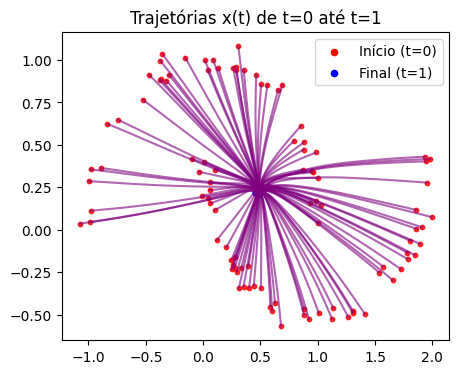

In [75]:
idx = torch.randint(0, X.shape[0], (100,))
x0 = X[idx]
t_span = torch.linspace(0, 1, 100)


with torch.no_grad():
    traj = ode(x0, t_span)
#traj = ode(x0, t_span)  # (steps, batch, 2)
#print("NFEs =", vf.nfe)

traj = traj.detach().cpu().numpy()

plt.figure(figsize=(5,4))
for i in range(len(x0)):
    plt.plot(traj[:,i,0], traj[:,i,1], color='purple', alpha=0.6)
    plt.scatter(traj[0,i,0], traj[0,i,1], color='red',alpha=0.8, s=10)   # início: t=0
    plt.scatter(traj[-1,i,0], traj[-1,i,1], color='blue',alpha=0.7, s=10) # final: t=1

red_marker = plt.scatter([], [], color='red', s=20, label='Início (t=0)')
blue_marker = plt.scatter([], [], color='blue', s=20, label='Final (t=1)')

plt.legend(handles=[red_marker, blue_marker])
plt.title("Trajetórias x(t) de t=0 até t=1")
plt.show()


* Vector field: quiver plot de $f(x,t)$ em grid 2D

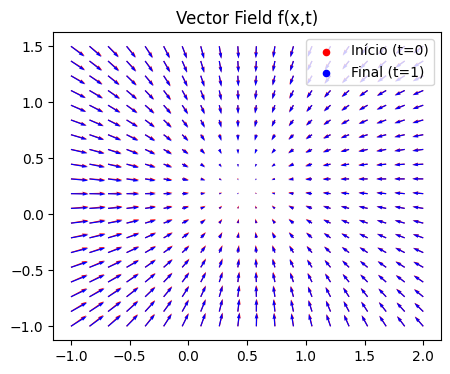

In [76]:
# criar grid 2D
xs = torch.linspace(-1, 2, 20).to(device)
ys = torch.linspace(-1, 1.5, 20).to(device)
grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')

points = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

# avaliar campo no tempo t=0
t0 = torch.zeros(points.shape[0], device=device) #cria um vetor de 900 zeros
t1 = torch.ones(points.shape[0], device=device) # tempo 1

with torch.no_grad():
    v0 = vf(t0, points).detach().cpu().numpy()
    v1 = vf(t1, points).detach().cpu().numpy()

grid_x = grid_x.detach().cpu().numpy()
grid_y = grid_y.detach().cpu().numpy()

v0x = v0[:,0].reshape(grid_x.shape)
v0y = v0[:,1].reshape(grid_y.shape)
v1x = v1[:,0].reshape(grid_x.shape)
v1y = v1[:,1].reshape(grid_y.shape)

plt.figure(figsize=(5,4))
plt.quiver(grid_x, grid_y, v0x, v0y, color='red')
plt.quiver(grid_x, grid_y, v1x, v1y, color='blue')

red_marker = plt.scatter([], [], color='red', s=20, label='Início (t=0)')
blue_marker = plt.scatter([], [], color='blue', s=20, label='Final (t=1)')

plt.legend(handles=[red_marker, blue_marker])
plt.title("Vector Field f(x,t)")
plt.show()

\* Transformação: $z ∼ N(0, I) → x = φ(z, 1)$


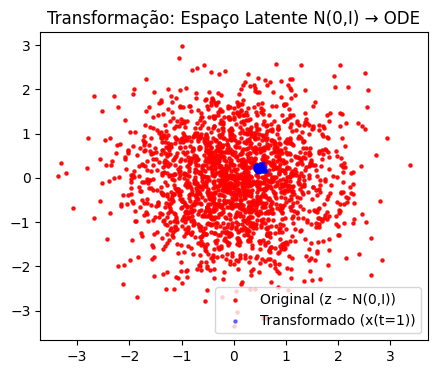

In [77]:
# amostrar pontos do espaço latente
z = torch.randn(2000, 2).to(device)

#t_span = torch.linspace(0, 1, 2)

# integrar até t=1
with torch.no_grad():
    x_final = ode(z,t_span.to(device)).detach()

x_final = x_final[-1]   # pegar último tempo
x_final = x_final.cpu().numpy()

z_np = z.cpu().numpy()
x_np = x_final
plt.figure(figsize=(5,4))
plt.scatter(z_np[:,0], z_np[:,1], s=5, alpha=0.9, color='red', label='Original (z ~ N(0,I))')
plt.scatter(x_np[:,0], x_np[:,1], s=5, alpha=0.5, color='blue', label='Transformado (x(t=1))')

plt.legend()
plt.title("Transformação: Espaço Latente N(0,I) → ODE")
plt.show()

Como pode ser observado, o treinamento não resultou em nada significativo, já que leva todos os pontos para um mesmo ponto. Pelos tres gráficos, é possivel notar esse comportamento.

4. Analisar:

Quantas NFEs (number of function evaluations)?

Como NFEs varia com rtol e atol ?

Comparar solvers: euler , rk4 , dopri5

In [78]:
solvers_config = [
    {'method': 'euler',  'rtol': None,  'atol': None},
    {'method': 'rk4',    'rtol': None,  'atol': None},
    {'method': 'dopri5', 'rtol': 1e-3,  'atol': 1e-4},
    {'method': 'dopri5', 'rtol': 1e-4,  'atol': 1e-5},
    {'method': 'dopri5', 'rtol': 1e-5,  'atol': 1e-6},
    {'method': 'dopri5', 'rtol': 1e-10,  'atol': 1e-10},
]


In [79]:
results = []
x0_ref = X

for cfg in solvers_config:
    method = cfg["method"]
    rtol = cfg["rtol"]
    atol = cfg["atol"]
    ode.solver = method

    if rtol is not None: ode.rtol = rtol
    if atol is not None: ode.atol = atol

    vf.nfe = 0

    start = time.time()
    traj = ode(x0_ref, t_span)
    elapsed = time.time() - start

    results.append((method,
                    rtol if rtol is not None else "default",
                    atol if atol is not None else "default",
                    int(vf.nfe),
                    float(elapsed)
                    ))

df = pd.DataFrame(results, columns=["solver", "rtol", "atol", "nfe", "time_s"])
print(tabulate(df, headers="keys", tablefmt="pretty", showindex=False))

+--------+---------+---------+------+---------------------+
| solver |  rtol   |  atol   | nfe  |       time_s        |
+--------+---------+---------+------+---------------------+
| euler  | default | default |  99  | 0.29784727096557617 |
|  rk4   | default | default | 396  | 0.7929980754852295  |
| dopri5 |  0.001  | 0.0001  |  32  | 0.14955854415893555 |
| dopri5 | 0.0001  |  1e-05  |  44  | 0.17332148551940918 |
| dopri5 |  1e-05  |  1e-06  |  68  | 0.22421503067016602 |
| dopri5 |  1e-10  |  1e-10  | 1646 |  6.664577484130859  |
+--------+---------+---------+------+---------------------+


**Análise dos métodos**

* Euler: O solver apresentou um NFE = 99 e um tempo de execução de 0.547s. Como o método de Euler é de passo fixo e t_span tem 100 pontos, ele realizou exatamente uma avaliação por intervalo de tempo. Mesmo sendo o algoritmo mais simples por passo, o custo total foi superior ao do Dopri5, já que possui um número fixo de passos independentemente da suavidade da trajetória.

* RK4: O método realizou 396 avaliações, levando 1.990s. Por ser um método de passo fixo que exige quatro avaliações do campo para cada incremento no tempo, seu custo foi exatamente quatro vezes superior ao de Euler ($4 \times 99$). O tempo de execução acompanhou esse aumento linear, como esperado, ou seja, para uma mesma discretização temporal, o RK4 é 4x mais pesado computacionalmente que o Euler.

* Dopri5 (Runge–Kutta Dormand–Prince): Por ser um integrador adaptativo, o Dopri5 apresentou o comportamento mais eficiente e, ao mesmo tempo, o mais sensível às configurações de precisão. Para maiores tolerâncias ($rtol=10^{-3}$, $atol=10^{-4}$), o método teve melhor performance comparado aos demais, com apenas 32 NFEs e um tempo de 0.309s. Isso mostra que o campo de vetores aprendido é suficientemente suave para permitir que o solver utilize passos de integração maiores, pulando partes do intervalo sem perder a precisão. Conforme as tolerâncias foram ficando mais rígidas, o número de avaliações sobe para 44 e 68 NFEs. No cenário de menor tolerância ($rtol/atol = 10^{-10}$), observou-se um aumento exponencial no custo computacional, atingindo 1442 NFEs e um tempo de 5.187s. Essa mudança ocorre porque, para garantir um resultado com precisão muito baixa, o algoritmo é forçado a reduzir drasticamente o tamanho dos passos, realizando muito mais chamadas à rede. Dessa forma, o solver Dopri5 pode ser a melhor escolha dependendo do equilíbrio entre velocidade de execução e precisão dos resultados, já que possui a vantagem de adaptação automática do passo de acordo com as tolerâncias.

Conclui-se que, em métodos adaptativos, tolerâncias muito pequenas aumentam consideravelmente o custo computacional, pois o solver reduz o tamanho dos passos e aumenta o número de avaliações de $f(t,x)$. Assim, NFEs podem funcionar como um bom indicador de custo, já que NFEs maiores tendem a resultar em execução mais lenta, como fica claro no comportamento do dopri5.

* Extra fora do escopo

 Tentativa de rodar o flowmacthing com vizualização de gráficos, já que não conseguimos resultados decentes com NeuralODE

In [80]:
vf = VectorField(features=2).to(device)
ode = NeuralODE(vf)
optimizer = torch.optim.Adam(vf.parameters(), lr=1e-3)

In [81]:
X_np, _ = make_moons(n_samples=2000, noise=0.05)
X = torch.tensor(X_np, dtype=torch.float32).to(device)
Z = torch.randn_like(X).to(device) # Ruído Gaussiano

In [82]:
epochs = 2000
batch_size = 256
vf.train()

for epoch in range(epochs):
    optimizer.zero_grad()

    # batch aleatório
    idx = torch.randperm(X.shape[0])[:batch_size]
    batch_x = X[idx] # t=1
    batch_z = Z[idx] # t=0

    # tempos aleatórios entre 0 e 1
    t = torch.rand(batch_x.shape[0], 1).to(device)

    # interpolação linear: x_t = (1-t)*z + t*x
    xt = (1 - t) * batch_z + t * batch_x

    # Velocidade Alvo (Target Velocity): v = x - z
    target_velocity = batch_x - batch_z
    pred_velocity = vf(t.squeeze(), xt)

    loss = torch.nn.functional.mse_loss(pred_velocity, target_velocity)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

Epoch    0 | Loss: 1.746281
Epoch  500 | Loss: 1.037777
Epoch 1000 | Loss: 1.112382
Epoch 1500 | Loss: 1.085088


Gráficos:

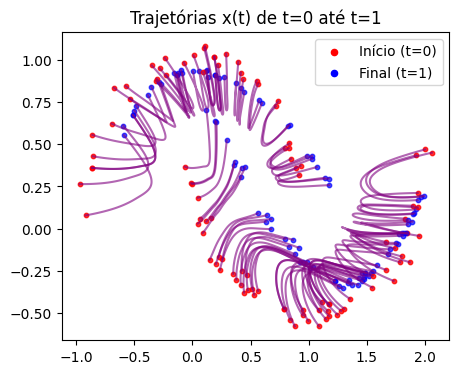

In [83]:
ode.eval()
idx = torch.randint(0, X.shape[0], (100,))
x0 = X[idx]
t_span = torch.linspace(0, 1, 100)

with torch.no_grad():
    traj = ode(x0, t_span)

traj = traj.detach().cpu().numpy()

plt.figure(figsize=(5,4))
for i in range(len(x0)):
    plt.plot(traj[:,i,0], traj[:,i,1], color='purple', alpha=0.6)
    plt.scatter(traj[0,i,0], traj[0,i,1], color='red',alpha=0.8, s=10)   # início: t=0
    plt.scatter(traj[-1,i,0], traj[-1,i,1], color='blue',alpha=0.7, s=10) # final: t=1

red_marker = plt.scatter([], [], color='red', s=20, label='Início (t=0)')
blue_marker = plt.scatter([], [], color='blue', s=20, label='Final (t=1)')

plt.legend(handles=[red_marker, blue_marker])
plt.title("Trajetórias x(t) de t=0 até t=1")
plt.show()


* Vector field: quiver plot de $f(x,t)$ em grid 2D

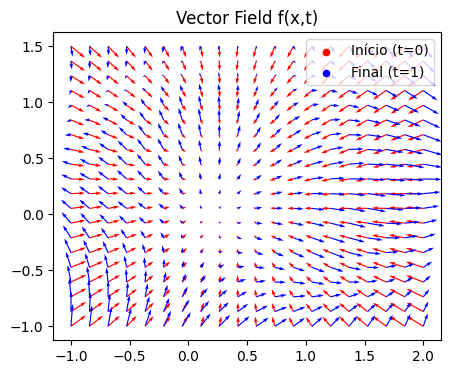

In [87]:
# criar grid 2D
xs = torch.linspace(-1, 2, 20)
ys = torch.linspace(-1, 1.5, 20)
grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')

points = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1).to(device)

# avaliar campo no tempo t=0
t0 = torch.zeros(points.shape[0], device=device) #cria um vetor de 900 zeros
t1 = torch.ones(points.shape[0], device=device) # tempo 1

with torch.no_grad():
    v0 = vf(t0, points).detach().cpu().numpy()
    v1 = vf(t1, points).detach().cpu().numpy()


v0x = v0[:,0].reshape(grid_x.shape)
v0y = v0[:,1].reshape(grid_y.shape)
v1x = v1[:,0].reshape(grid_x.shape)
v1y = v1[:,1].reshape(grid_y.shape)

plt.figure(figsize=(5,4))
plt.quiver(grid_x, grid_y, v0x, v0y, color='red')
plt.quiver(grid_x, grid_y, v1x, v1y, color='blue')

red_marker = plt.scatter([], [], color='red', s=20, label='Início (t=0)')
blue_marker = plt.scatter([], [], color='blue', s=20, label='Final (t=1)')

plt.legend(handles=[red_marker, blue_marker])
plt.title("Vector Field f(x,t)")
plt.show()

* Transformação: $z ∼ N(0, I) → x = φ(z, 1)$


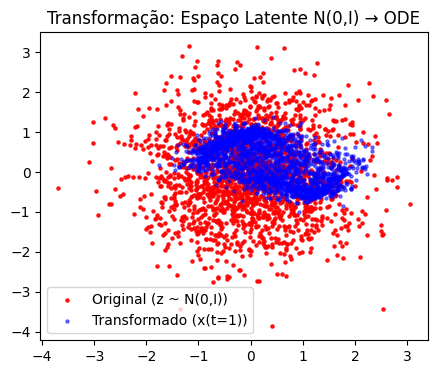

In [89]:
# amostrar pontos do espaço latente
z = torch.randn(2000, 2).to(device)

# t_span = torch.linspace(0, 1, 2)

# integrar até t=1
with torch.no_grad():
    x_final = ode(z,t_span.to(device)).detach()

x_final = x_final[-1]   # pegar último tempo
x_final = x_final.cpu().numpy()

z_np = z.cpu().numpy()
x_np = x_final
plt.figure(figsize=(5,4))
plt.scatter(z_np[:,0], z_np[:,1], s=5, alpha=0.9, color='red', label='Original (z ~ N(0,I))')
plt.scatter(x_np[:,0], x_np[:,1], s=5, alpha=0.5, color='blue', label='Transformado (x(t=1))')

plt.legend()
plt.title("Transformação: Espaço Latente N(0,I) → ODE")
plt.show()

* Comparação das Abordagens:

ODE Puro: Nos gráficos, vemos que o método falhou quase que totalmente. Apesar de o modelo tentar processar os pontos, o resultado final (em azul) ficou concentrado em um pequeno borrão no centro. Ele não conseguiu aprender o formato das luas e apenas moveu todos os pontos para um único ponto médio. Isso mostra que, nesse caso, treinar a trajetória inteira, sem uma estratégia de fluxo (como o Flow Matching) é mais difícil para obter bons resultados.

Flow Matching: Nesse treinamento o cenário muda. O modelo conseguiu transformar a nuvem de pontos vermelhos até que eles assumissem o formato semelhante das duas luas. Os pontos azuis agora tem formato das curvas das luas. Isso prova que o Flow Matching é mais eficiente para treinar a rede como trasnformar os dados de um lugar para o outro, mantendo a estrutura e os detalhes do desenho mais semelhantes ao original.